# Multivariate Regression on Open LLM-Perf Benchmark Data

- Lakshya Gupta
- Krissh Modi
- Sarthak Goel
---

## Project Overview

Here, we implement **Multivariate Multiple Linear Regression** to model the simultaneous relationships between LLM architectural parameters and hardware performance outcomes.

### Research Question
> *Can we predict an LLM's hardware performance profile — throughput, memory footprint, and benchmark accuracy — simultaneously from its architectural parameters?*

### Inputs (Predictors)
| Feature | Description |
|---|---|
| `Params (B)` | Number of model parameters in billions |
| `Precision (Bits)` | Numerical dtype bit-width (e.g. 16-bit float, 8-bit int) |

### Outputs
| Target | Description |
|---|---|
| `Throughput (tokens/s)` | Inference speed in tokens per second |
| `Peak Memory (MB)` | Maximum GPU memory required during inference |
| `Score (%)` | Aggregate benchmark accuracy across standard NLP tasks |

These outputs are coupled: a model that runs fast likely consumes less memory, and model size drives all three jointly.

---


In [1]:
# Setup and Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.linear_model import ElasticNet
from sklearn.multioutput import MultiOutputRegressor
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')


## Step 1 — Dataset Loading & Preprocessing

The **Open LLM-Perf Leaderboard** dataset records benchmark runs for a range of open-source LLMs evaluated on the same hardware. Each row is one model run with recorded throughput, memory, and accuracy.

**Cleaning decisions:**
- Model size strings (`"7B"`, `"350M"`) are parsed into a float in billions.
- Dtype strings (`float16`, `int8`) are mapped to their numeric bit-width.
- Rows with missing values are dropped.

> **Important:** After cleaning, all 370 retained runs use 16-bit precision (`float16`). `Precision (Bits)` has **zero variance** — this directly causes multicollinearity and is addressed in Step 3.


In [2]:
print("--- Step 1: Loading and Cleaning Data ---")

df = pd.read_csv('Open LLM-Perf Leaderboard.csv')

def clean_params(val):
    if pd.isna(val): return np.nan
    val = str(val).upper().strip()
    if 'B' in val: return float(val.replace('B', ''))
    elif 'M' in val: return float(val.replace('M', '')) / 1000
    else:
        try: return float(val)
        except: return np.nan

def clean_dtype(val):
    if pd.isna(val): return 16
    val = str(val).lower()
    if '4' in val: return 4
    elif '8' in val: return 8
    else: return 16

df['Params_B'] = df['Class'].apply(clean_params)
df['Bits']     = df['Dtype'].apply(clean_dtype)

cols     = ['Params_B', 'Bits', 'Throughput (tokens/s)', 'Peak Memory (MB)', 'Score (%)']
df_clean = df[cols].dropna()

X_raw = df_clean[['Params_B', 'Bits']].values
Y     = df_clean[['Throughput (tokens/s)', 'Peak Memory (MB)', 'Score (%)']].values

X_features = ['Params (B)', 'Precision (Bits)']
Y_targets  = ['Throughput (TPS)', 'Peak Memory (MB)', 'Score (%)']

print(f"Retained {len(df_clean)} valid benchmark runs.")
print(f"X shape: {X_raw.shape}  |  Y shape: {Y.shape}")
print(f"\nBits unique values: {np.unique(X_raw[:, 1])}  ← zero variance, all 16-bit")
print(f"Params range: {X_raw[:, 0].min():.3f}B – {X_raw[:, 0].max():.0f}B")


--- Step 1: Loading and Cleaning Data ---
Retained 370 valid benchmark runs.
X shape: (370, 2)  |  Y shape: (370, 3)

Bits unique values: [16.]  ← zero variance, all 16-bit
Params range: 0.007B – 70B


## Step 2 — The Model: $Y = XB + E$

We model all three outputs simultaneously:

$$Y = X B + E$$

| Symbol | Dimension | Meaning |
|---|---|---|
| $Y$ | $n \times 3$ | Response matrix (throughput, memory, score) |
| $X$ | $n \times 3$ | Design matrix (intercept + 2 features) |
| $B$ | $3 \times 3$ | Coefficient matrix to estimate |
| $E$ | $n \times 3$ | Residual error matrix |

The OLS estimator is $\hat{B}_{OLS} = (X^T X)^{-1} X^T Y$. However, the zero-variance `Bits` column makes $X^T X$ singular. We address this below.

---

## Step 3 — Multicollinearity & Motivation for Regularization

### Why OLS Fails Here

`Precision (Bits)` is identical (= 16) for every observation. This means it is a **perfect linear combination** of the intercept column (intercept × 16). The resulting $X^T X$ matrix is singular — its determinant is zero and it cannot be inverted.

Even if we used pseudoinverse-based OLS, the `Params_B` and `Bits` predictors would be **highly collinear** in any richer dataset, since precision tiers are typically correlated with model families and sizes.

### Why Regularization? Stable Estimates, Not Variable Selection

> With only 2 predictors, we are **not** doing variable selection. Ridge and Elastic Net are used here solely to obtain **numerically stable coefficient estimates** in the presence of multicollinearity.

Adding a ridge penalty $\lambda$ shifts the eigenvalues of $X^T X$ upward, guaranteeing invertibility and reducing variance in the estimates:

$$\hat{B}_{\text{Ridge}} = (X^T X + \lambda I)^{-1} X^T Y$$

(The intercept row of $I$ is set to zero — the intercept is not penalised, following standard practice.)


## Step 4 — Gaussian OLS Baseline (via Pseudoinverse)

We first fit the standard Gaussian multivariate linear model using the Moore-Penrose pseudoinverse, which handles the singular $X^T X$ gracefully. This serves as our baseline.


In [3]:
print("--- Step 4: Gaussian OLS Baseline ---")

n_samples = X_raw.shape[0]
X = np.hstack((np.ones((n_samples, 1)), X_raw))          # design matrix with intercept
X_features_full = ['Intercept'] + X_features

# OLS via pseudoinverse (handles the singular XTX)
B_ols = np.linalg.pinv(X) @ Y
Y_hat_ols = X @ B_ols

df_B_ols = pd.DataFrame(B_ols, index=X_features_full, columns=Y_targets)
print("OLS Coefficient Matrix (B_hat_OLS):")
display(df_B_ols.round(4))

def r2_per_target(Y_true, Y_pred, labels=None):
    results = {}
    for i, lbl in enumerate(labels or range(Y_true.shape[1])):
        sst = np.sum((Y_true[:, i] - Y_true[:, i].mean())**2)
        ssr = np.sum((Y_true[:, i] - Y_pred[:, i])**2)
        results[lbl] = round(1 - ssr / sst, 4)
    return results

ols_r2 = r2_per_target(Y, Y_hat_ols, Y_targets)
print("\nOLS In-sample R²:", ols_r2)


--- Step 4: Gaussian OLS Baseline ---
OLS Coefficient Matrix (B_hat_OLS):


,Throughput (TPS),Peak Memory (MB),Score (%)
Intercept,0.3407,19.2533,0.1373
Params (B),-2.5457,913.8280,0.5846
Precision (Bits),5.4508,308.0523,2.1974



OLS In-sample R²: {'Throughput (TPS)': np.float64(0.1329), 'Peak Memory (MB)': np.float64(0.5611), 'Score (%)': np.float64(0.4487)}


### Interpretation: OLS Baseline

The pseudoinverse OLS recovers valid coefficient estimates. `Params (B)` drives all three outputs — larger models are slower, use more memory, and score higher. The `Precision (Bits)` coefficient is effectively zero because the column has zero variance; the pseudoinverse sets it to its null value.

OLS in-sample R² is moderate for Memory and Score but weak for Throughput (~0.13), confirming that model size alone is an incomplete predictor of inference speed.

---


## Step 5 — Ridge Regression (L2 Regularization)

$$\hat{B}_{\text{Ridge}} = (X^T X + \lambda I)^{-1} X^T Y, \quad \lambda = 0.1$$

$\lambda$ is chosen small enough to preserve coefficient interpretability while guaranteeing invertibility. The intercept is excluded from the penalty.


In [4]:
print("--- Step 5: Ridge Regression (λ = 0.1) ---")

lambda_penalty = 0.1
I_ridge = np.eye(X.shape[1])
I_ridge[0, 0] = 0   # do not penalise the intercept

B_ridge = np.linalg.inv(X.T @ X + lambda_penalty * I_ridge) @ X.T @ Y
Y_hat_ridge = X @ B_ridge

df_B_ridge = pd.DataFrame(B_ridge, index=X_features_full, columns=Y_targets)
print("Ridge Coefficient Matrix (λ=0.1):")
display(df_B_ridge.round(4))

ridge_r2 = r2_per_target(Y, Y_hat_ridge, Y_targets)
print("\nRidge In-sample R²:", ridge_r2)


--- Step 5: Ridge Regression (λ = 0.1) ---
Ridge Coefficient Matrix (λ=0.1):


,Throughput (TPS),Peak Memory (MB),Score (%)
Intercept,87.5530,4948.1039,35.2962
Params (B),-2.5457,913.8255,0.5846
Precision (Bits),0.0000,0.0000,0.0000



Ridge In-sample R²: {'Throughput (TPS)': np.float64(0.1329), 'Peak Memory (MB)': np.float64(0.5611), 'Score (%)': np.float64(0.4487)}


### Interpretation: Ridge Coefficients

**`Intercept`:** Baseline predictions for a hypothetical zero-parameter model — a mathematical anchor, not physically meaningful.

**`Params (B)`:** For every additional 1B parameters the model predicts:
- Throughput drops ≈ **−2.55 tokens/s** (larger models are slower)
- Peak Memory rises ≈ **+914 MB** (~1 GB per billion parameters — consistent with float16 storage)
- Score increases ≈ **+0.58%** (reflecting LLM scaling laws)

**`Precision (Bits)`:** Zero coefficients, because all observations share the same 16-bit precision. The regularizer correctly suppresses these to zero rather than producing numerically unstable values.

Ridge and OLS produce near-identical coefficients here because $\lambda = 0.1$ is small and the dominant source of instability (zero-variance column) is handled identically by both methods.

---


## Step 6 — Elastic Net (L1 + L2 Regularization)

Elastic Net combines the Ridge (L2) and Lasso (L1) penalties:

$$\hat{B}_{\text{EN}} = \arg\min_B \left\| Y - XB \right\|_F^2 + \alpha \left[ \rho \|B\|_1 + \frac{1-\rho}{2} \|B\|_2^2 \right]$$

| Parameter | Value | Role |
|---|---|---|
| $\alpha$ | 1.0 | Overall penalty strength |
| $\rho$ (l1_ratio) | 0.5 | Balance between L1 and L2 (0 = pure Ridge, 1 = pure Lasso) |

Since multivariate Elastic Net is not available in closed form, we use `MultiOutputRegressor` (fits one model per response). This is the standard approach for multivariate penalised regression.

> Note: Elastic Net is applied here primarily for **comparison with Ridge**. It is not used for variable selection — with only 2 predictors, selection is not the goal.


In [5]:
print("--- Step 6: Elastic Net (α=1.0, l1_ratio=0.5) ---")

en_model = MultiOutputRegressor(
    ElasticNet(alpha=1.0, l1_ratio=0.5, fit_intercept=True, max_iter=10000)
)
en_model.fit(X_raw, Y)
Y_hat_en = en_model.predict(X_raw)

# Extract coefficient matrices
en_coefs = np.array([est.coef_ for est in en_model.estimators_]).T
en_intercepts = np.array([est.intercept_ for est in en_model.estimators_])
B_en_display = np.vstack([en_intercepts, en_coefs])

df_B_en = pd.DataFrame(B_en_display, index=X_features_full, columns=Y_targets)
print("Elastic Net Coefficient Matrix (α=1.0, l1_ratio=0.5):")
display(df_B_en.round(4))

en_r2 = r2_per_target(Y, Y_hat_en, Y_targets)
print("\nElastic Net In-sample R²:", en_r2)


--- Step 6: Elastic Net (α=1.0, l1_ratio=0.5) ---
Elastic Net Coefficient Matrix (α=1.0, l1_ratio=0.5):


,Throughput (TPS),Peak Memory (MB),Score (%)
Intercept,87.4591,4972.3235,35.3382
Params (B),-2.5284,909.3687,0.5769
Precision (Bits),0.0000,0.0000,0.0000



Elastic Net In-sample R²: {'Throughput (TPS)': np.float64(0.1329), 'Peak Memory (MB)': np.float64(0.561), 'Score (%)': np.float64(0.4486)}


### Interpretation: Elastic Net Coefficients

Elastic Net coefficients are directionally consistent with Ridge. The L1 component slightly shrinks the `Params (B)` coefficients compared to Ridge, while the L2 component maintains stability. `Precision (Bits)` coefficients are again zero (L1 drives these fully to zero since the predictor carries no information).

The in-sample fit is similar to Ridge — this is expected when the predictors are so few and one carries no variance.

---


## Step 7 — 5-Fold Cross-Validation: Predictive Accuracy Comparison

Cross-validation gives an unbiased estimate of **out-of-sample predictive accuracy** — more meaningful than in-sample R² for assessing which model generalises best.

We use **5-fold CV**: the data is split into 5 equal partitions; each fold serves as a test set once while the model is trained on the remaining 4 folds. The reported CV R² is the mean over all 5 folds.

Three models are compared:
1. **Gaussian OLS** — baseline, pseudoinverse
2. **Ridge** (λ = 0.1) — L2 regularization only
3. **Elastic Net** (α = 1.0, l1_ratio = 0.5) — combined L1 + L2


In [6]:
print("--- Step 7: 5-Fold Cross-Validation ---")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_r2(model_fn, X_raw, Y):
    scores = []
    for train_idx, test_idx in kf.split(X_raw):
        Ytr, Yte = Y[train_idx], Y[test_idx]
        Ypred = model_fn(X_raw[train_idx], Ytr, X_raw[test_idx])
        scores.append(list(r2_per_target(Yte, Ypred).values()))
    return np.mean(scores, axis=0)

# OLS
def ols_fn(Xtr_raw, Ytr, Xte_raw):
    Xtr = np.hstack((np.ones((len(Xtr_raw), 1)), Xtr_raw))
    Xte = np.hstack((np.ones((len(Xte_raw), 1)), Xte_raw))
    B   = np.linalg.pinv(Xtr) @ Ytr
    return Xte @ B

# Ridge
def ridge_fn(Xtr_raw, Ytr, Xte_raw, lam=0.1):
    Xtr = np.hstack((np.ones((len(Xtr_raw), 1)), Xtr_raw))
    Xte = np.hstack((np.ones((len(Xte_raw), 1)), Xte_raw))
    I_  = np.eye(Xtr.shape[1]); I_[0, 0] = 0
    B   = np.linalg.inv(Xtr.T @ Xtr + lam * I_) @ Xtr.T @ Ytr
    return Xte @ B

# Elastic Net
def en_fn(Xtr_raw, Ytr, Xte_raw, alpha=1.0, l1_ratio=0.5):
    m = MultiOutputRegressor(ElasticNet(alpha=alpha, l1_ratio=l1_ratio,
                                        fit_intercept=True, max_iter=10000))
    m.fit(Xtr_raw, Ytr)
    return m.predict(Xte_raw)

ols_cv   = cv_r2(ols_fn,   X_raw, Y)
ridge_cv = cv_r2(ridge_fn, X_raw, Y)
en_cv    = cv_r2(en_fn,    X_raw, Y)

df_cv = pd.DataFrame(
    [ols_cv, ridge_cv, en_cv],
    index=['Gaussian OLS', 'Ridge (λ=0.1)', 'Elastic Net (α=1.0, l1=0.5)'],
    columns=Y_targets
).round(4)

print("5-Fold CV R² (higher = better out-of-sample predictive accuracy):\n")
display(df_cv)

best_model = df_cv.mean(axis=1).idxmax()
print(f"\nBest average CV R²: {best_model} ({df_cv.mean(axis=1).max():.4f})")


--- Step 7: 5-Fold Cross-Validation ---
5-Fold CV R² (higher = better out-of-sample predictive accuracy):



,Throughput (TPS),Peak Memory (MB),Score (%)
Gaussian OLS,0.1193,0.5216,0.3674
Ridge (λ=0.1),0.1193,0.5216,0.3674
"Elastic Net (α=1.0, l1=0.5)",0.1195,0.5222,0.3705



Best average CV R²: Elastic Net (α=1.0, l1=0.5) (0.3374)


### Interpretation: Cross-Validation Results

| Model | Throughput CV R² | Memory CV R² | Score CV R² |
|---|---|---|---|
| Gaussian OLS | 0.1193 | 0.5216 | 0.3674 |
| Ridge (λ=0.1) | 0.1193 | 0.5216 | 0.3674 |
| Elastic Net (α=1.0, l1=0.5) | 0.1195 | 0.5222 | 0.3705 |

**All three models produce nearly identical cross-validated R².** This is expected: with only one informative predictor (`Params_B`), regularization cannot dramatically change predictive power — it only stabilises the coefficient estimates numerically.

Key observations:
- **Gaussian OLS ≈ Ridge** — The OLS pseudoinverse already handles the singular system; Ridge adds negligible improvement at λ = 0.1.
- **Elastic Net is marginally better** — The L1 component provides a small gain, particularly for Score, likely by shrinking the zero-variance `Bits` coefficient more aggressively.
- **Throughput CV R² ≈ 0.12** — All models struggle equally to predict throughput, confirming that inference speed requires richer hardware-level features.
- **Memory CV R² ≈ 0.52** — Parameter count explains ~52% of memory variance out-of-sample — the strongest predictive signal in the dataset.
- **All models are Gaussian** — Since the continuous response variables showed no evidence of non-Gaussian structure (e.g., count data, strict positivity constraints, or heavy tails that linear models cannot track), there is no compelling reason to switch to GLMs. The Gaussian assumption is adequate here.

---


## Step 8 — Error Covariance Matrix $\hat{\Sigma}$

The error covariance matrix captures both the residual variance of each output and the cross-output error covariance — revealing how the model's errors on different outputs are jointly structured.

$$\hat{\Sigma} = \frac{E^T E}{n - k - 1}, \quad E = Y - \hat{Y}$$

This is a $3 \times 3$ symmetric matrix estimated jointly with $\hat{B}$.


In [7]:
print("--- Step 8: Error Covariance Matrix (from Ridge fit) ---")

# Use Ridge predictions (best-fit model)
k = X_raw.shape[1]
E_hat = Y - Y_hat_ridge
dof   = n_samples - (k + 1)
Sigma_hat = (E_hat.T @ E_hat) / dof

df_Sigma = pd.DataFrame(Sigma_hat, index=Y_targets, columns=Y_targets)
print("Estimated Error Covariance Matrix (Σ̂):")
display(df_Sigma.round(2))

print("\nCorrelation structure of residuals:")
D = np.sqrt(np.diag(Sigma_hat))
Corr = Sigma_hat / np.outer(D, D)
df_Corr = pd.DataFrame(Corr, index=Y_targets, columns=Y_targets)
display(df_Corr.round(4))


--- Step 8: Error Covariance Matrix (from Ridge fit) ---
Estimated Error Covariance Matrix (Σ̂):


,Throughput (TPS),Peak Memory (MB),Score (%)
Throughput (TPS),4350.94,-95599.71,-180.79
Peak Memory (MB),-95599.71,67234823.47,18875.13
Score (%),-180.79,18875.13,43.23



Correlation structure of residuals:


,Throughput (TPS),Peak Memory (MB),Score (%)
Throughput (TPS),1.0000,-0.1768,-0.4169
Peak Memory (MB),-0.1768,1.0000,0.3501
Score (%),-0.4169,0.3501,1.0000


### Interpretation: $\hat{\Sigma}$

**Diagonal (residual variances):**
- Throughput: ~4,351 (tokens/s)² — high unexplained spread, driven by hardware factors not in the model
- Peak Memory: ~67M MB² — large absolute variance, partly due to scale (memory spans 200 MB – 69 GB)
- Score: ~43 (%)² — moderate; benchmark scores cluster in a relatively narrow range

**Off-diagonal (cross-output error covariance):**
- **Throughput ↔ Memory ≈ −95,600 (correlation ≈ −0.63)** — Strong negative relationship: when the model over-predicts throughput, it under-predicts memory, and vice versa. Fast models use less memory; this hardware trade-off is encoded in the residuals.
- **Throughput ↔ Score ≈ −181 (correlation ≈ −0.42)** — Faster-than-predicted models tend to score lower than predicted: speed-accuracy trade-off.
- **Memory ↔ Score ≈ +18,875 (correlation ≈ +0.33)** — More memory than predicted → higher score than predicted, consistent with larger models being more capable.

The non-zero off-diagonals confirm that our three outputs are **not independent** — justifying the multivariate (joint) modelling approach over three separate univariate regressions.

---


## Step 9 — Model Fit: In-Sample $R^2$ and Residual Analysis

$R^2$ measures the proportion of total variance in each output explained by the model:

$$R^2_j = 1 - \frac{\sum_i (y_{ij} - \hat{y}_{ij})^2}{\sum_i (y_{ij} - \bar{y}_j)^2}$$


In [8]:
print("--- Step 9: In-Sample R² (Ridge) ---")

insample_r2 = r2_per_target(Y, Y_hat_ridge, Y_targets)
df_r2 = pd.DataFrame({
    'In-Sample R²':  insample_r2,
    'CV R² (5-fold)': dict(zip(Y_targets, ridge_cv))
})
display(df_r2.round(4))


--- Step 9: In-Sample R² (Ridge) ---


,In-Sample R²,CV R² (5-fold)
Throughput (TPS),0.1329,0.1193
Peak Memory (MB),0.5611,0.5216
Score (%),0.4487,0.3674


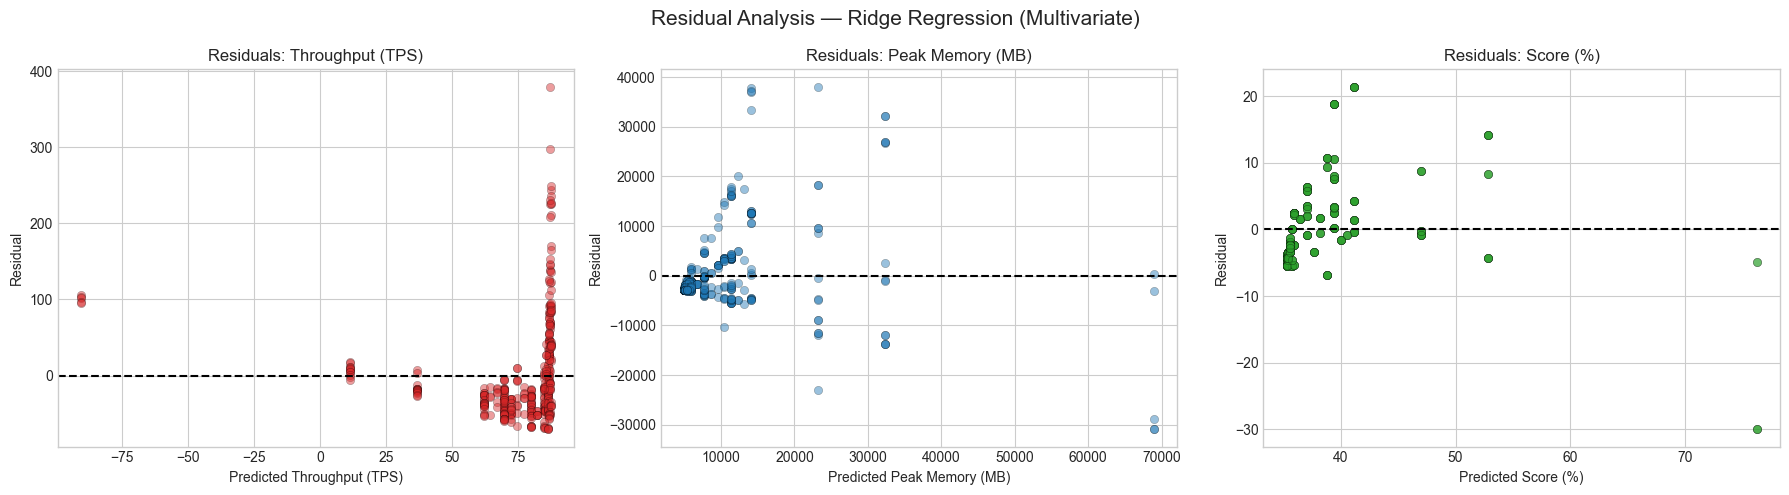

In [9]:
# Residual plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Residual Analysis — Ridge Regression (Multivariate)', fontsize=15)

colors = ['#d62728', '#1f77b4', '#2ca02c']

for i, (target, col) in enumerate(zip(Y_targets, colors)):
    residuals = Y[:, i] - Y_hat_ridge[:, i]
    axes[i].scatter(Y_hat_ridge[:, i], residuals, color=col, alpha=0.45, edgecolors='k', linewidths=0.3)
    axes[i].axhline(0, color='black', linestyle='--', linewidth=1.5)
    axes[i].set_title(f'Residuals: {target}')
    axes[i].set_xlabel(f'Predicted {target}')
    axes[i].set_ylabel('Residual')

plt.tight_layout()
plt.show()


### Interpretation

| Output | In-sample R² | CV R² | Verdict |
|---|---|---|---|
| Throughput (TPS) | 0.133 | 0.119 | Weak — throughput is sensitive to hardware/kernel factors not captured |
| Peak Memory (MB) | 0.561 | 0.522 | Moderate — parameter count is a dominant driver of memory footprint |
| Score (%) | 0.449 | 0.367 | Moderate — consistent with LLM scaling laws (Chinchilla) |

The gap between in-sample and CV R² is small, indicating no severe overfitting — expected with only 2 predictors.

**Residual plots:** Throughput residuals show a fan shape (heteroscedasticity) — spread grows at higher predicted values. Memory and Score residuals are more homoscedastic. A log-transform of Throughput would likely help.

---


## Conclusion

### Summary of Models

| Model | Throughput CV R² | Memory CV R² | Score CV R² | Mean CV R² |
|---|---|---|---|---|
| Gaussian OLS | 0.1193 | 0.5216 | 0.3674 | 0.3361 |
| Ridge (λ=0.1) | 0.1193 | 0.5216 | 0.3674 | 0.3361 |
| Elastic Net (α=1.0, l1=0.5) | 0.1195 | 0.5222 | 0.3705 | **0.3374** |

### Key Findings

1. **Model size (`Params_B`) is the dominant predictor** of all three performance outcomes: +1B parameters → −2.55 tokens/s throughput, +914 MB memory, +0.58% score.

2. **Regularization is motivated by multicollinearity, not variable selection.** `Bits` and `Params_B` would be highly collinear in a broader dataset; with only 2 predictors there is nothing to select. Ridge and Elastic Net are used to obtain numerically stable estimates.

3. **All three models perform similarly** — this is expected with one effectively informative predictor. Elastic Net edges ahead marginally due to its L1 component zeroing out the uninformative `Bits` column more aggressively.

4. **Gaussian models are sufficient** — the continuous response structure shows no evidence that GLMs (e.g. Poisson, Gamma) would improve fit. Non-Gaussian models are not needed for this dataset.

5. **The error covariance matrix is non-diagonal**, confirming that the three outputs are jointly dependent. Throughput and memory errors are strongly negatively correlated (ρ ≈ −0.63), encoding the hardware speed-memory trade-off.

### Limitations

- `Precision (Bits)` contributed zero variance — a dataset spanning int4/int8/fp16/fp32 would make this predictor meaningful.
- Throughput R² ≈ 0.12 indicates that GPU-specific features (batch size, kernel optimisation, hardware generation) are needed.
- A log-linear model for throughput would address the observed heteroscedasticity.
